# Pauli-Path Simulation of Quantum Circuits

## Introduction

Pauli-Path Propagation is a relatively recent classical algorithm that has found remarkable success in simulating quantum dynamics of many-body systems consisting of a large number (> 100) of qubits -- systems which were previously considered to be classically intractable. 

In circuit-based quantum computation, we are interested in computing expectation value of an observable $O$ for a state $|\psi\rangle$, which is obtained by evolving an initial state $|\psi_0\rangle$ by sequentially applying gates of the circuit.  This is the standard **Schrödinger picture** of quantum mechanics, where the states evolve while observables remain fixed. Let $U$ represent the unitary transformation describing the action of the entire circuit on the state. Almost always, $|\psi_0\rangle = |0\rangle$, so that $|\psi\rangle = U |0\rangle$, and hence computing the expectation value of an observable $O$ requires:
\begin{align*}
    \langle O \rangle = \langle  \psi |  O |  \psi \rangle = \langle 0 | U^\dagger O U | 0 \rangle.
\end{align*}

Pauli-path propagation works in the **Heisenberg picture** where the observable evolves 'backwards in time', to be evaluated against the initial state $|\psi_0\rangle$. The evolved observable is nothing but $U^\dagger O U$. In gate-based quantum simulations that we are focusing on, this simply involves working backwards through a circuit, applying the Heisenberg evolution to an observable one gate at a time. 


## Overview of Pauli-Path Propagation

As we saw above, in Pauli-path simulation we are focused on computing the evolved observable $U^\dagger O U$. We assume that the initial observable $O$ is a Sparse Pauli Observable in the sense that it has a sparse representation of the form $$ O = \sum_{P \in \mathcal P} a_P P,$$  where $\mathcal P$ is a subset of the $n$-qubit Pauli-basis $\mathcal P^{(n)} = \{I, X, Y, Z\}^{\otimes\, n}$ consisting of all Pauli-word operators. Here, 'sparse representation' can be taken to mean that $\mathcal P$ is a polynomially-bounded subset of the Pauli basis $\mathcal P^{(n)}$ (which, of course, has exponential size $4^n$). We also assume without loss of generality that the $n$-qubit unitary $U$ representing the unitary transformation of a given circuit can be represented as a series of Pauli rotations as follows:
\begin{align*}
    U = \prod_{j\in[J]}U_j(\theta_{j}) = \prod_{j\in[J]}\mathrm{e}^{-i\theta_j \sigma_j/2},
\end{align*}
where each $\sigma_j$ is an $n$-qubit Pauli operator, and each parameter $\theta_j \in [-\pi,\pi)$. This can be achieved by transpiling the original circuit into a new circuit with a basis set consisting only of rotation gates, such as $\{RX, RY, RZ, RZZ\}$.



### Branching and Merging of Paulis


The behavior of a Pauli operator $P$ under the application of a Pauli-rotation gate $U_\sigma(\theta) = \mathrm{e}^{-i(\theta/2) \sigma}$ depends on whether $P$ commutes with the gate generator $\sigma$ or not:

\begin{align*}
U_\sigma(\theta)^{\dagger} P U_\sigma(\theta) =
\begin{cases}
P &\quad \text{if} \quad [P, \sigma] = 0 \\
\cos(\theta)P + i\sin(\theta) (\sigma \cdot P) &\quad \text{if} \quad \{P, \sigma\}=0.
\end{cases}
\end{align*}

The above equation, which is of fundamental importance to Pauli-Path dynamics, is in fact easy to derive on noting that $U_\sigma(\theta) = \cos(\theta/2)I -i\sin(\theta/2)\sigma,$ where we have used $\sigma^2 = I$.
 

Let $O_k$ be the observable after the action of $k$ gates.
\begin{align*}
    O_k := U_k^{\dagger}U_{k-1}^{\dagger}\dots U_1OU_1U_2 \dots U_k.
\end{align*}
Using the Pauli basis, $O_{k}$ can always be decomposed as
\begin{align*}
    O_k = \sum_{P\in\mathcal{P}_k}c_{P}^{(k)}P,
\end{align*}
where $\mathcal{P}_k$ is a subset of all possible $n$-qubit Pauli operators with non-zero coefficients.

Denoting $\mathcal P_{k+1}$ to be the set of Pauli-terms representing the evolved observable $O_{k+1}$ on applying the gate $U_{k+1}$, we have, due to the fundamental branching-and-merging equation, that $$|\mathcal P_k| \leq |\mathcal P_{k+1}| \leq 2|\mathcal P_k|, $$

i.e., the number of Pauli operators representing the observable grows in general with each applied gate, potentially leading to the worst-case scaling of $\mathcal O (2^n)$.


## A small (but exact) simulation to start with

Let us now try an actual Pauli-Path simulation using the `'pauli-path'` device on the BQ platform! 

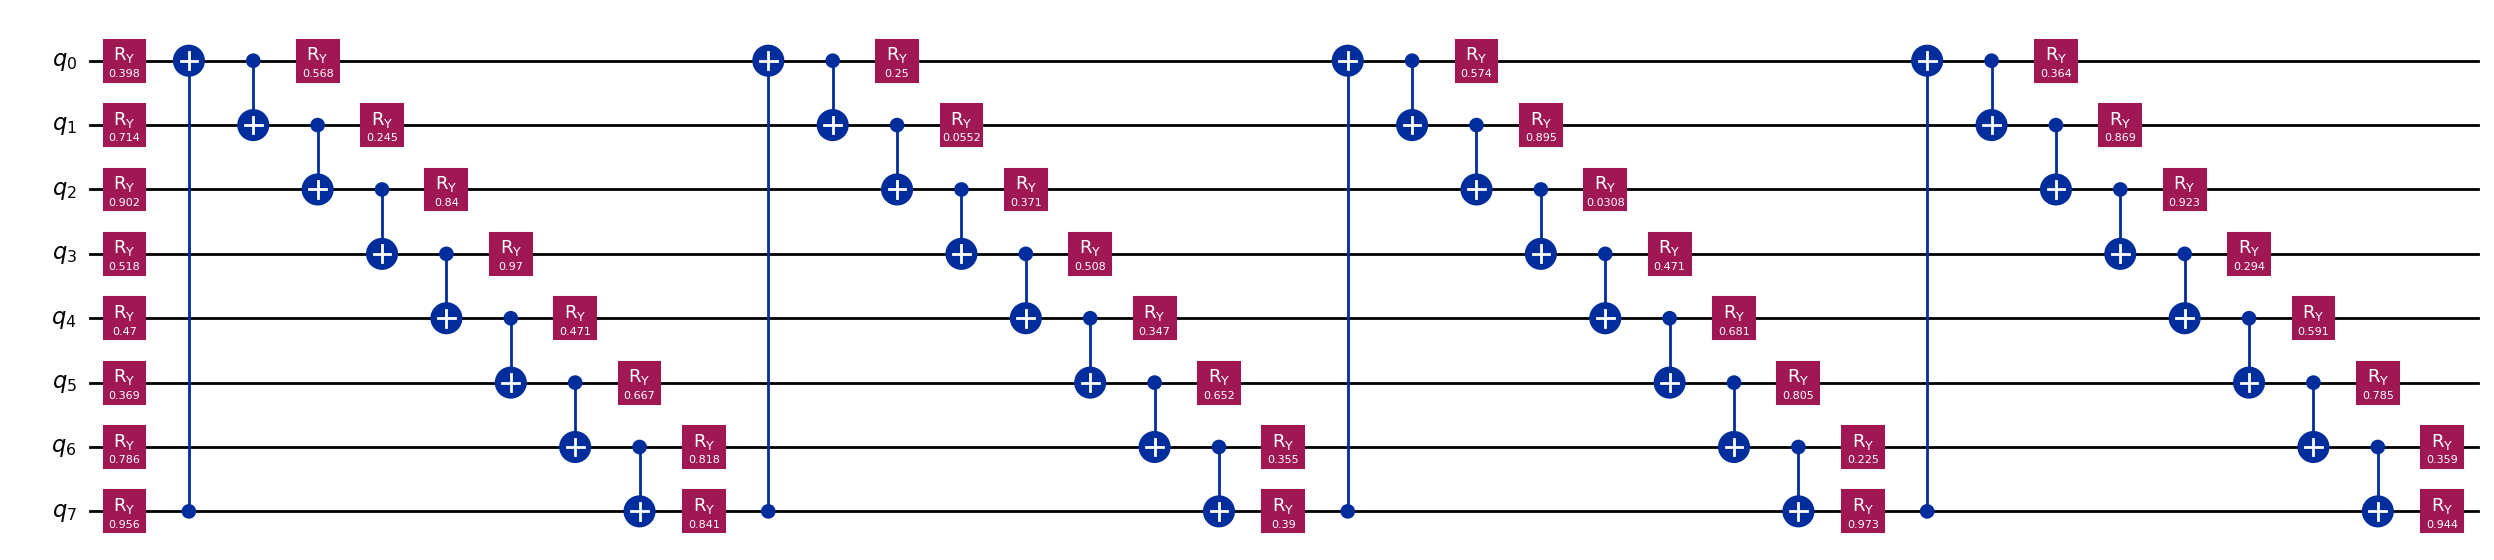

In [1]:
# Make the circuit we want to run. We choose a generic two-local circuit

import numpy as np
from qiskit.circuit.library import n_local

n_qubits = 8
num_layers = 4
entanglement = "circular"

qc = n_local(
    n_qubits,
    rotation_blocks="ry",
    entanglement_blocks="cx",
    reps=num_layers,
    entanglement=entanglement,
)

rng = np.random.default_rng(101)

# We reverse the parameters so that increasing layers will preserve the initial part of the observable evolution.
# Recall that in PPS, observable evolution proceeds backwards, reversing the order of the gates in the circuit.
qc.assign_parameters(rng.random(qc.num_parameters)[::-1], inplace=True)

# choose an observable to find the expecation value of
pauli_sum = [
    ("ZZ" + "I" * (n_qubits - 2), 0.5),
    ("I" * (n_qubits - 2) + "XX", -1.5),
]
# So, pauli_sum is equal to 0.5*'ZZI...I' - 1.5*'I...IXX'

# draw the circuit
qc.draw("mpl", fold=100)

In [2]:
# Initialize BQ API

import bluequbit

bq = bluequbit.init()
# bq = bluequbit.init ("< API Key >")

[BQ-PYTHON-SDK][WARNING] - Beta version 0.17.0b1 of BlueQubit Python SDK is being used.


[BQ-PYTHON-SDK][INFO] - Using execution mode from environment variable BLUEQUBIT_EXECUTION_MODE: local


[BQ-PYTHON-SDK][WARNING] - Using custom endpoint https://dev.app.bluequbit.io/api/v1


In [4]:
# run exact pauli-path simulation
result = bq.run(qc, device="pauli-path", pauli_sum=pauli_sum)

# print the exact expectation_value
print(f"expectation value: {result.expectation_value}")

expectation value: 0.11541958149700024


## Coefficient Truncation

In the warm-up example above, the observable actually evolves to encompass the full Pauli-basis (minus the identity)! That is, there are $4^8-1 = 65,535$ Pauli terms in the representation of $O_k$ (as $k$ increases). It is obvious that such a scenario will lead to memory overflow if the number of qubits were higher.

Various truncation strategies, based on approximations to the exact Heisenberg evolution, have been proposed to deal with the problem of exponential scaling in Pauli-Path Simulation. The simplest of these is to discard any Pauli term whose coefficient is smaller than a chosen truncation threshold $\delta$, i.e., after each gate application we only keep those $P$ such that $c_P$ satisfies $|c_P| \geq \delta$. 

The intuition here is that for small enough $\delta$, discarding such Pauli terms with negligible coefficient is a judicious way to keep exponential growth of Paulis in check while also maintaining accuracy of expectation value computations. By chosing smaller and smaller $\delta$, one hopes to get as close to the exact simulation as desired. The main constraint in this approach is the memory required to store and manipulate the requisite number of Paulis. 

Because of unitarity, one can in fact show that at each step $k$ of the simulation, we have that the number of Pauli terms satisfy 
$$ |\mathcal P_k| \leq \frac{\|O\|^2}{\delta^2}, $$ where $\|O\|$ denotes the norm of the initial observable. We note that the above estimate is asymptotically optimal for generic circuits in the following sense: numerical evidence suggests that for random circuits, halving $\delta$ can lead to an approximate four-fold increase in the number of Pauli terms.

In the BQ platform, one can choose a truncation threshold by setting the `options` parameter as follows:

```options = {'pauli_path_truncation_threshold': 1e-3}```


<br> Let us re-run the previous simulation, but this time with a choice of truncation threshold.

In [5]:
# re-run with truncation threshold
result_new = bq.run(
    qc, device="pauli-path", pauli_sum=pauli_sum, options={"pauli_path_truncation_threshold": 1e-3}
)

# print the approximate expectation_value
print(f"expectation value (approximation): {result_new.expectation_value}")

# print relative error
print(
    f"relative error: {(result_new.expectation_value - result.expectation_value) / (result.expectation_value) * 100:.2f}%"
)

expectation value (approximation): 0.12119790506074347
relative error: 5.01%


<br> We remark that with coefficient truncation enabled, it turns out that there are only 18,804 Pauli terms present in the simulation. At the same time, we get a sufficiently good approximation to the exact expectation value. This is the crux of the coefficient truncation method -- trading off some accuracy in expectation value for significantly improved memory (and runtime) requirements! For more on how effective coefficient truncation is and for protocols for choosing an 'optimal' $\delta$, we refer to BQ-team's recent research [[3]](#ref-3) on Pauli-Path Simulations.  

## Recreating the IBM Utility Experiment Results

In [[1]](#ref-1), the IBM team reported on running quantum experiments on their then state-of-the-art 127-qubit Eagle processor. They successfully implemented the kicked Ising model for T=20 Trotter steps, and speculated that it was infeasible to simulate the quantum dynamics classically using available algorithms. This claim was based on extrapolation from their numerical simulations of these circuits using Matrix-Product-State and Tensor-Network methods. However, soon afterwards, it was shown in [[2]](#ref-2) that Pauli-Path Simulation can effectively recreate the results of the IBM quantum experiment.

Let us now do the same and run a Pauli-path simulation of the IBM kicked Ising model circuits on the BQ platform! 

In [6]:
from qiskit import QuantumCircuit

# helper call that returns all the nearest neighbors on the
# IBM 127 qubit system heavy hex lattice
from bluequbit.library.helpers.hardware_connectivites import IBM_127_HEAVY_HEX_MAP

# helper call that returns qiskit Pauli objects given the
# qubits idxs for the X,Y, and Z operators in the Pauli string
from bluequbit.library.helpers.pauli_sum import construct_pauli_from_idx_lists

num_qubits = 127
num_trotter_steps = 20

rzz_angle = -np.pi / 2
rx_angle_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1, 1.5707]

# Create the list of circuits to run, one for each value of rx_angle

qcs = []

# construct the circuit for each choice of the rx_angle
for rx_angle in rx_angle_list:
    qc = QuantumCircuit(num_qubits)
    for _ in range(num_trotter_steps):
        for edge in IBM_127_HEAVY_HEX_MAP:
            qc.rzz(rzz_angle, edge[0], edge[1])
        for i in range(num_qubits):
            qc.rx(rx_angle, i)
    qcs.append(qc)

# Let us print the number of gates in one these circuits
print(qcs[0].count_ops())

OrderedDict([('rzz', 2880), ('rx', 2540)])


In [7]:
# RECREATING THE IBM EXPERIMENT TO ESTIMATE <Z_62>
# Construct a single weight Pauli operator with a Pauli Z at qubit idx 62
idx_lists = [[], [], [62]]
pauli_op = construct_pauli_from_idx_lists(idx_lists, num_qubits)
pauli_sum = [(pauli_op.to_label(), 1.0)]

# list to store the expectation value <Z_62> for each choice of the rx_angle
expectation_values = []

# set the Pauli path coefficient threshold
options = {"pauli_path_truncation_threshold": 8e-4}

# run PPS

for j, qc in enumerate(qcs):
    results = bq.run(qc, device="pauli-path", pauli_sum=pauli_sum, options=options)
    exp_val = results.expectation_value
    rt = results.run_time_ms
    expectation_values.append(exp_val)
    print(f"θ_X = {rx_angle_list[j]}: expectation value = {exp_val}; runtime(ms) = {rt}")

θ_X = 0: expectation value = 1.0; runtime(ms) = 0
θ_X = 0.1: expectation value = 0.9957937553232452; runtime(ms) = 1000
θ_X = 0.2: expectation value = 0.9782716359342183; runtime(ms) = 2000
θ_X = 0.3: expectation value = 0.9095692336430325; runtime(ms) = 1000
θ_X = 0.4: expectation value = 0.8592520405122102; runtime(ms) = 2000
θ_X = 0.5: expectation value = 0.7726371006956175; runtime(ms) = 2000
θ_X = 0.6: expectation value = 0.5346940089364863; runtime(ms) = 3000
θ_X = 0.7: expectation value = 0.3663994651384841; runtime(ms) = 3000
θ_X = 0.8: expectation value = 0.21836947661010786; runtime(ms) = 4000
θ_X = 1: expectation value = 0.010364854926823841; runtime(ms) = 4000
θ_X = 1.5707: expectation value = 0.0; runtime(ms) = 1000


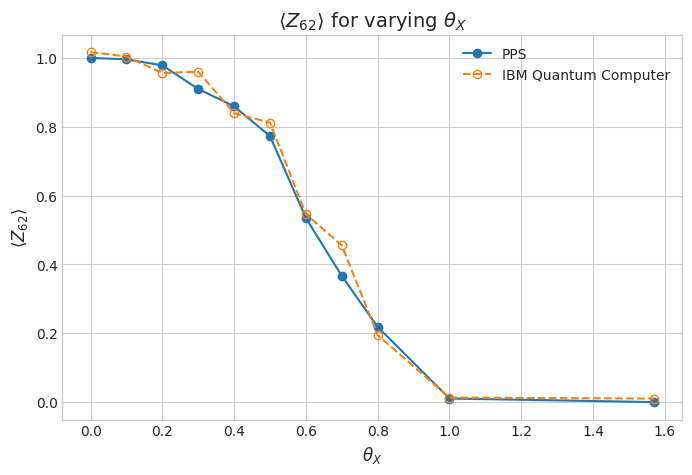

In [8]:
# Plot expectation values vs. theta_X

ibm_error_mitigated_exp_vals = [
    1.0168885899596067,
    1.0038748336672971,
    0.9561588556424929,
    0.9596643467379465,
    0.839467630327344,
    0.8118590711547804,
    0.5464099544570664,
    0.455185839969086,
    0.19469376775026115,
    0.013018321146103315,
    0.010163339885627119,
]

from matplotlib import pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_title(r"$\langle Z_{62} \rangle$ for varying $\theta_X$", fontsize=14)
ax.set_xlabel(r"$\theta_X$", fontsize=12)
ax.set_ylabel(r"$\langle Z_{62} \rangle $", fontsize=12)

ax.plot(rx_angle_list, expectation_values, "o-", label="PPS")

ax.plot(
    rx_angle_list,
    ibm_error_mitigated_exp_vals,
    "o--",
    markerfacecolor="none",
    label="IBM Quantum Computer",
)

ax.legend()

plt.show()

### Convergence of Expectation Value

As we mentioned earlier, by choosing smaller and smaller values of truncation threshold $\delta$, one hopes to get as close to the exact expectation value as possible. Let us end with a demonstration of this phenomenon for the IBM utility circuit. (We caution however that it not always the case that expectation values converge as $\delta$ is systematically decreased.) 

delta = 1.0: expectation value = 0.0
delta = 0.5: expectation value = 0.0
delta = 0.25: expectation value = 0.4360030884085211
delta = 0.125: expectation value = 0.8968015013629593
delta = 0.0625: expectation value = 0.8630190320516513
delta = 0.03125: expectation value = 0.9478682600589542
delta = 0.015625: expectation value = 0.9303904289242256
delta = 0.0078125: expectation value = 0.9115721528561196
delta = 0.00390625: expectation value = 0.9108828316717585
delta = 0.001953125: expectation value = 0.9092492197921503
delta = 0.0009765625: expectation value = 0.9085331433025337
delta = 0.00048828125: expectation value = 0.9143612007548058
delta = 0.000244140625: expectation value = 0.9153697445892943


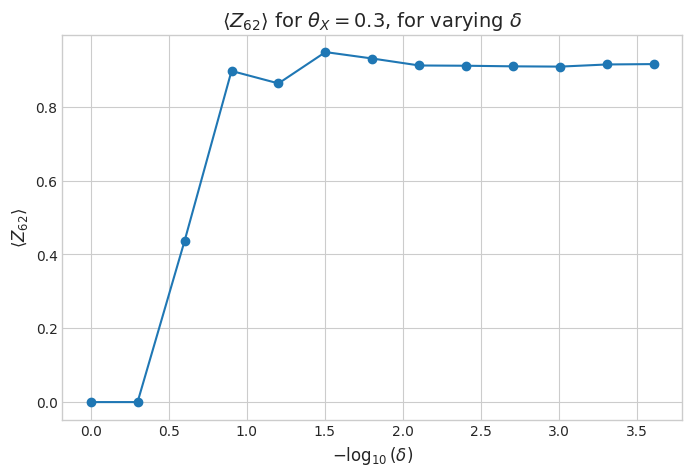

In [9]:
# RECREATING THE CONVERGENCE CURVE FOR θ_X = 0.3
rzz_angle = -np.pi / 2
rx_angle = 0.3

# list of the coefficient thresholds (delta) in decreasing order
deltas = [1 / 2**i for i in range(13)]

# list to store the expectation value <Z_62> for each choice of delta
expectation_values = []

# construct circuit for this pair of rzz and rx angles
qc = QuantumCircuit(num_qubits)
for _ in range(num_trotter_steps):
    for edge in IBM_127_HEAVY_HEX_MAP:
        qc.rzz(rzz_angle, edge[0], edge[1])
    for i in range(num_qubits):
        qc.rx(rx_angle, i)

for delta in deltas:
    # set the Pauli path coefficient threshold
    options = {
        "pauli_path_truncation_threshold": delta,
    }

    results = bq.run(qc, device="pauli-path", pauli_sum=pauli_sum, options=options)
    exp_val = results.expectation_value
    expectation_values.append(exp_val)
    print(f"delta = {delta}: expectation value = {exp_val}")


fig, ax = plt.subplots(figsize=(8, 5))

ax.set_title(r"$\langle Z_{62} \rangle$ for $\theta_X = 0.3$, for varying $\delta$", fontsize=14)
ax.set_xlabel(r"$-\log_{10}(\delta)$", fontsize=12)
ax.set_ylabel(r"$\langle Z_{62} \rangle $", fontsize=12)


ax.plot(-np.log10(deltas), expectation_values, "o-")

plt.show()

<h2 id="references">References</h2>

<a id="ref-1"></a> [1] Y. Kim, A. Eddins, S. Anand et al., “Evidence for the utility of quantum computing before fault tolerance,” *Nature*, vol. 618, pp. 500–505, 2023. DOI: 10.1038/s41586-023-06096-3.

<a id="ref-2"></a> [2] T. Begušić et al., “Fast and converged classical simulations of evidence for the utility of quantum computing before fault tolerance,” *Sci. Adv.*, vol. 10, no. adk4321, 2024. DOI: 10.1126/sciadv.adk4321.

<a id="ref-3"></a> [3] H. Gharibyan, S. Hariprakash, M. Z. Mullath, and V. P. Su, “A Practical Guide to using Pauli Path Simulators for Utility-Scale Quantum Experiments,” arXiv:2507.10771, 2025. Available: [https://arxiv.org/abs/2507.10771](https://arxiv.org/abs/2507.10771).